In [2]:

import json
import requests
import torch
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
sys.path.append("..")
from utils.balanced_builders_hdf import *
from models.autoencoder_classifier import *
from config import *
from collections import defaultdict
from sklearn.metrics.pairwise import cosine_similarity
from final_pipline.IG import *
import pickle
from scipy.ndimage import gaussian_filter
from final_pipline.xrd_sum import *
from sklearn.metrics import pairwise_distances
from final_pipline.IG_prototypes import *
import h5py
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform

In [3]:
cs = build_balanced_cs_loaders_from_h5(
    h5_path=xrd_dataset,
    per_class_cs=105000,   
    batch_size=256,
    val_split=0.1,
    test_split=0.1,
    seed=42,
    num_workers=4,
)

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = DeepConvAutoencoderClassifier(
    input_length=cs["input_len"],
    latent_dim=64,
    cls_dim=128,
    num_classes=cs["num_classes"],
    use_projection_head=True
).to(device)

# Load state_dict safely
state_dict = torch.load(CS_Cls, map_location=device, weights_only=True)

model.load_state_dict(state_dict)

model.eval();

In [7]:
with h5py.File(IG_database_CS, "r") as f:
    ig_train_igs = f["attributions"][:]        
    ig_train_classes = f["true_classes"][:]    

In [9]:
# Example: plot sample index 2
#idx = 2
#plot_ig_only( ig_train_igs[idx],true_class=ig_train_classes[idx])

In [6]:
protos, counts = build_ig_class_prototypes(
    IG_database_CS,
    num_classes=7
)
np.save(
    IG_Classes_Prototypes_CS,
    protos
)
print("Saved prototypes. counts =", counts)

Building IG prototypes: 100%|██████████| 30/30 [00:26<00:00,  1.15it/s]

Saved prototypes. counts = [83967 83974 83966 83979 83969 83957 83964]


In [8]:
idx = 10
sample_ig = ig_train_igs[idx]

print("Entropy:", ig_entropy(sample_ig))
print("Top regions:", top_regions(sample_ig))


Entropy: 6.761647
Top regions: [(775, 795, 785, 10.289077758789062), (598, 618, 608, 5.2783284187316895), (1315, 1335, 1325, 3.4579460620880127), (201, 221, 211, 3.101550340652466), (675, 695, 685, 2.7908666133880615), (865, 885, 875, 2.5993282794952393)]


In [8]:
#plot_mean_xrd_patterns_by_class_separate(
#    cs["train_loader"],
#    class_names= cs["class_names"],
#    max_patterns_per_class=7000)

In [6]:
class_names = [
    'triclinic',
    'monoclinic',
    'orthorhombic',
    'tetragonal',
    'trigonal',
    'hexagonal',
    'cubic'
]

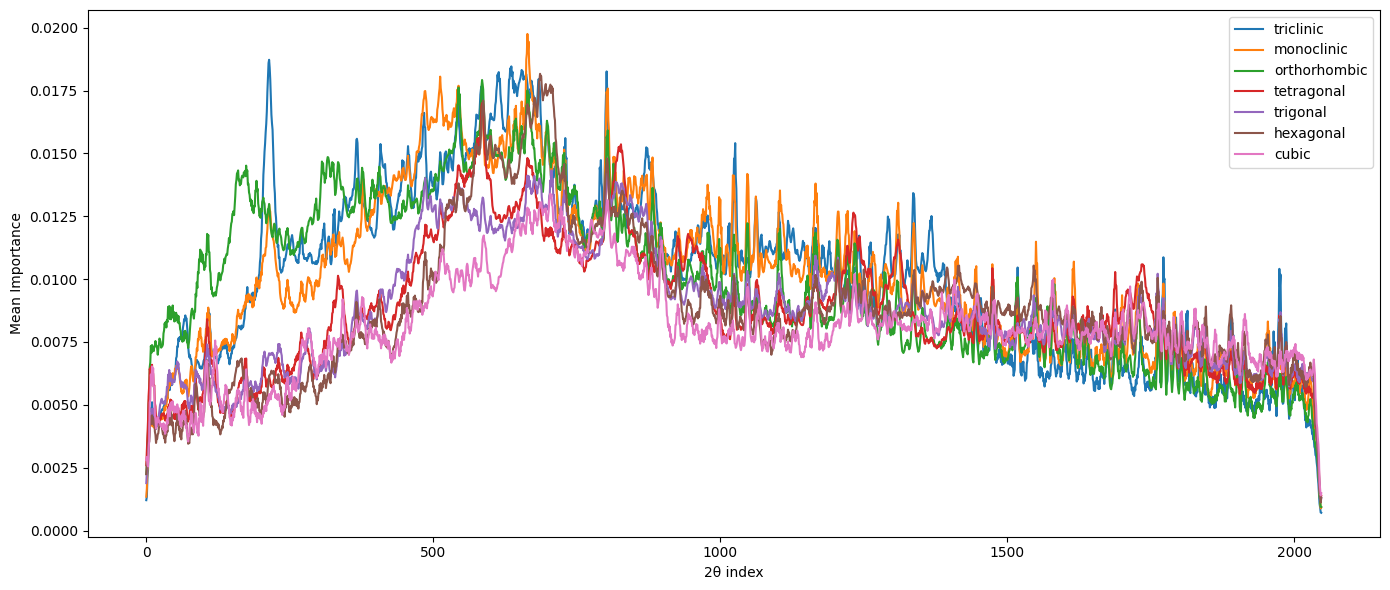

In [ ]:
ig_abs = np.abs(ig_train_igs)

# 2️ Compute mean IG per class
mean_igs = {}

for class_idx, class_name in enumerate(class_names):
    mask = ig_train_classes == class_idx
    mean_curve = ig_abs[mask].mean(axis=0)
    mean_igs[class_name] = mean_curve

# 3️ Plot
plt.figure(figsize=(14,6))

for class_name in class_names:
    plt.plot(mean_igs[class_name], label=class_name)

plt.xlabel("2θ index")
plt.ylabel("Mean Importance")
plt.legend()
plt.tight_layout()
plt.show()

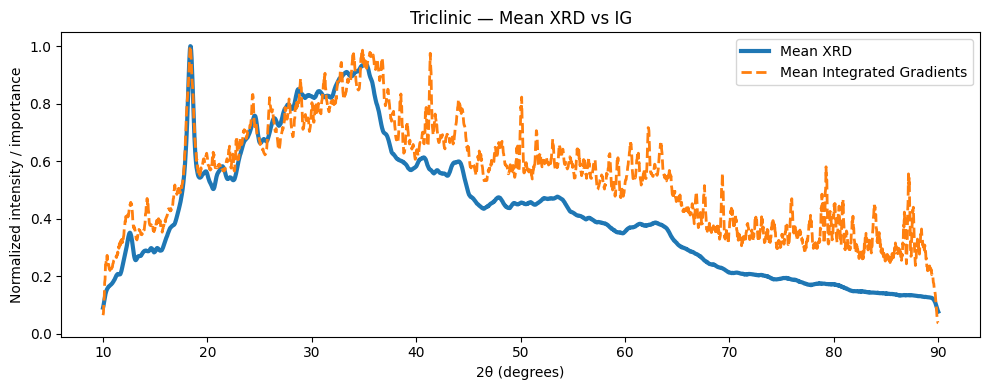

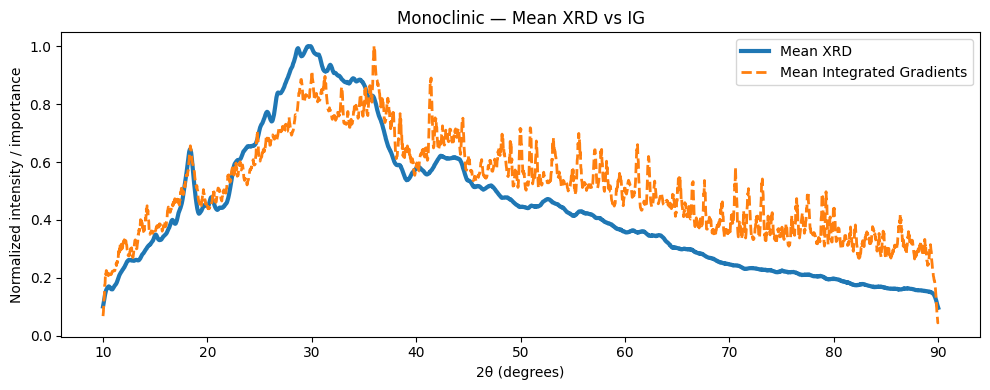

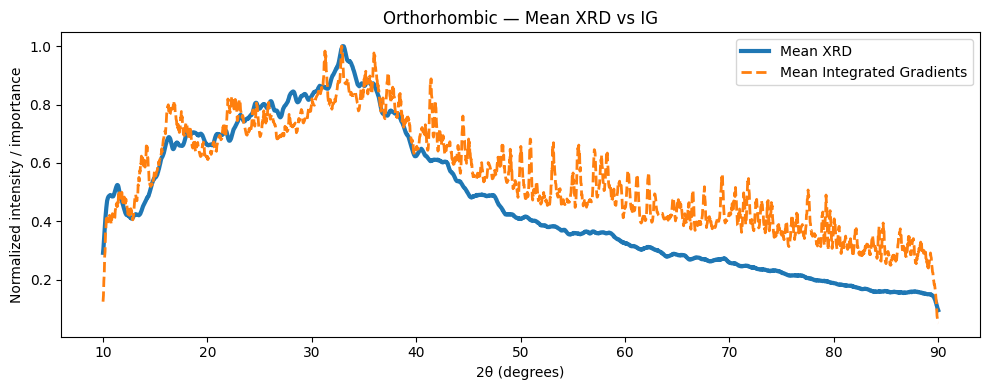

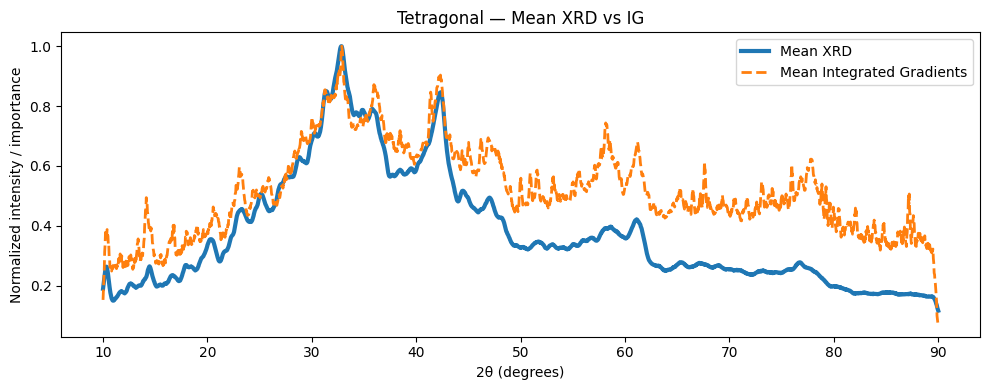

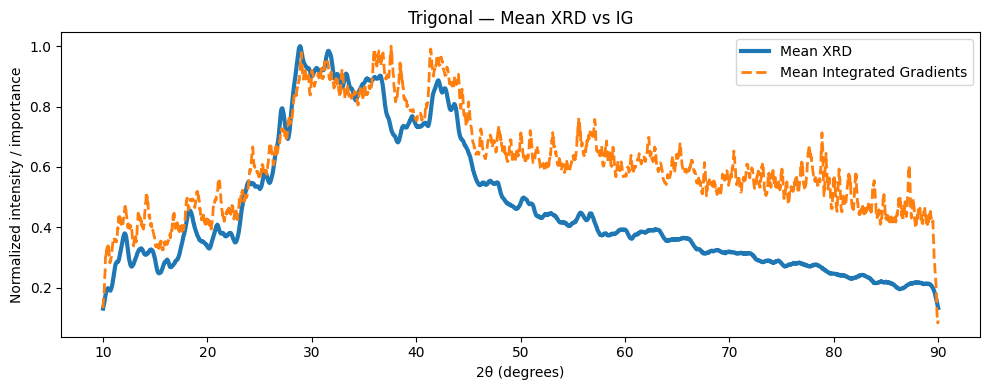

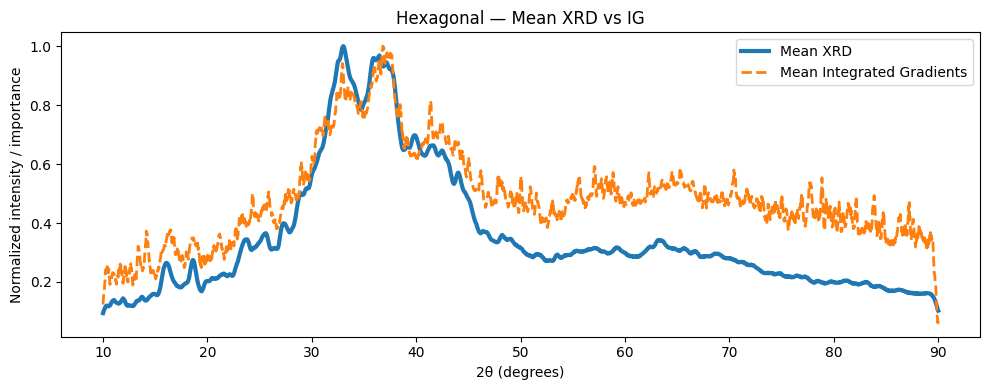

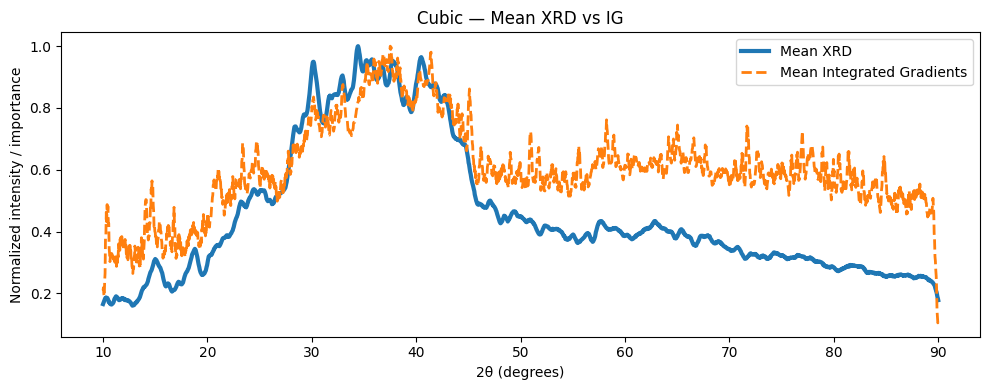

In [10]:
mean_xrd = compute_mean_xrd_by_class(
    cs["train_loader"],
    num_classes=len(class_names),
)
# 2θ axis
two_theta = np.linspace(10, 90, ig_abs.shape[1])

for class_idx, class_name in enumerate(class_names):

    xrd = mean_xrd[class_idx]
    ig  = mean_igs[class_name]

    # normalize (important for comparison)
    xrd_norm = xrd / np.max(xrd)
    ig_norm  = ig / np.max(ig)

    plt.figure(figsize=(10,4))

    # Mean XRD
    plt.plot(
        two_theta,
        xrd_norm,
        linewidth=3,
        label="Mean XRD",
    )

    # Mean IG
    plt.plot(
        two_theta,
        ig_norm,
        linestyle="--",
        linewidth=2,
        label="Mean Integrated Gradients",
    )

    plt.title(f"{class_name.capitalize()} — Mean XRD vs IG")
    plt.xlabel("2θ (degrees)")
    plt.ylabel("Normalized intensity / importance")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [ ]:
for i, name in enumerate(class_names):
    ratio = attention_ratio(mean_xrd[i], mean_igs[name], two_theta)
    print(f"{name}: low/high attention ratio = {ratio:.2f}")

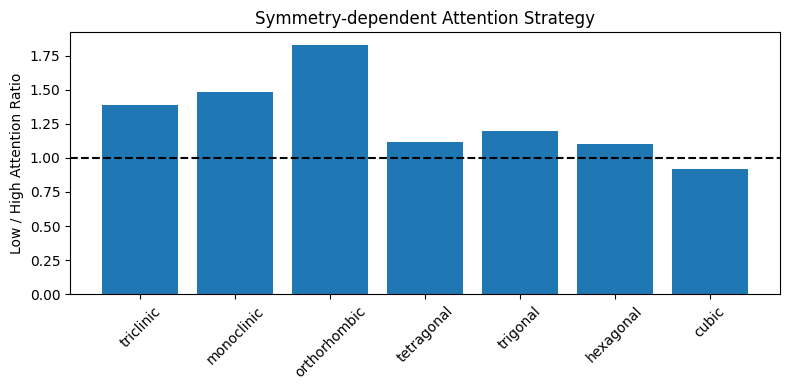

In [12]:
ratios = [
    1.39, 1.48, 1.83, 1.12, 1.20, 1.10, 0.92
]

plt.figure(figsize=(8,4))
plt.bar(class_names, ratios)

plt.axhline(1.0, linestyle="--", color="black")

plt.ylabel("Low / High Attention Ratio")
plt.title("Symmetry-dependent Attention Strategy")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



Top IG regions per crystal system:

Class: triclinic
  2θ [17.97, 18.75] (center=18.36)  score=0.8980
  2θ [35.56, 36.34] (center=35.95)  score=0.8560
  2θ [32.43, 33.21] (center=32.82)  score=0.8354
  2θ [35.99, 36.77] (center=36.38)  score=0.8346
  2θ [30.87, 31.65] (center=31.26)  score=0.8335
  2θ [35.13, 35.91] (center=35.52)  score=0.8281

Class: monoclinic
  2θ [35.60, 36.38] (center=35.99)  score=0.9016
  2θ [30.87, 31.65] (center=31.26)  score=0.8925
  2θ [32.47, 33.25] (center=32.86)  score=0.8882
  2θ [35.17, 35.95] (center=35.56)  score=0.8403
  2θ [40.99, 41.77] (center=41.38)  score=0.8390
  2θ [36.03, 36.81] (center=36.42)  score=0.8374

Class: orthorhombic
  2θ [32.47, 33.25] (center=32.86)  score=0.9375
  2θ [30.87, 31.65] (center=31.26)  score=0.9255
  2θ [35.60, 36.38] (center=35.99)  score=0.9011
  2θ [40.99, 41.77] (center=41.38)  score=0.8546
  2θ [32.04, 32.82] (center=32.43)  score=0.8526
  2θ [31.34, 32.12] (center=31.73)  score=0.8353

Class: tetragonal
  2θ 

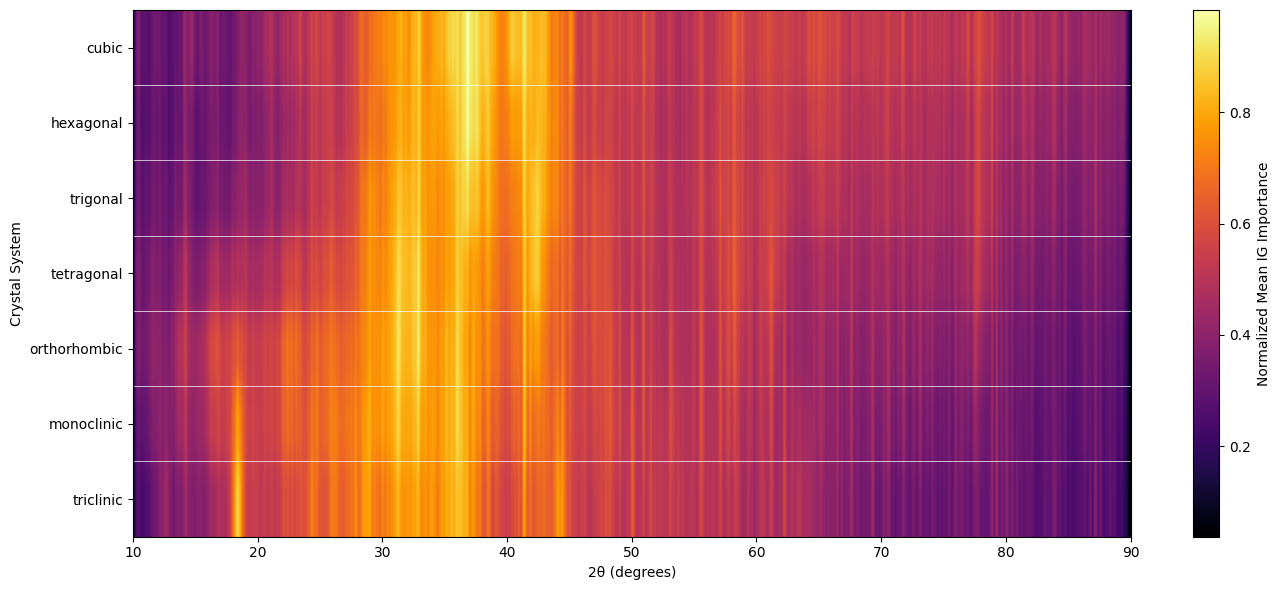

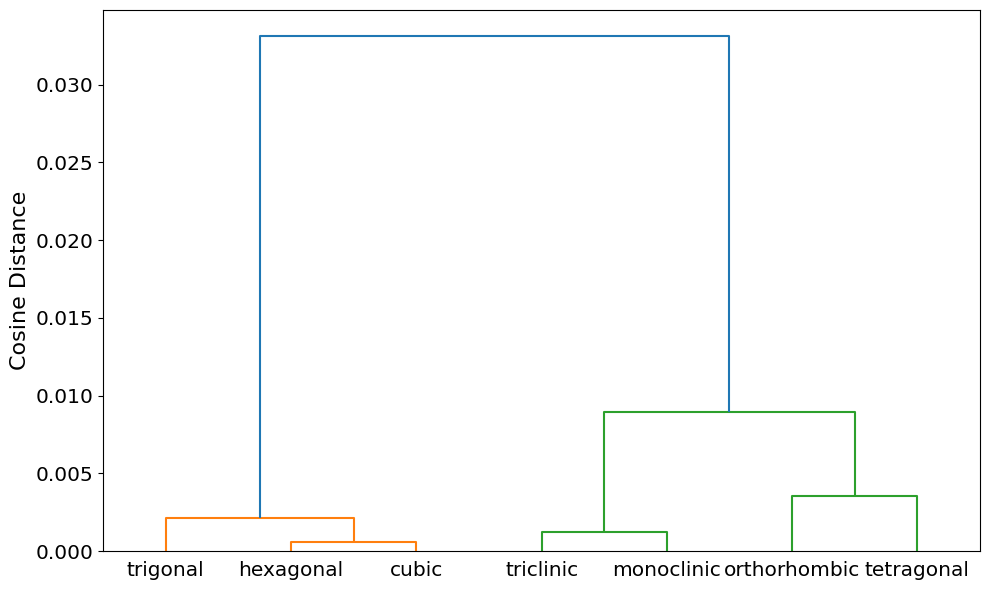


Mean cosine inter-class distance: 0.011025607585906982
Mean correlation inter-class distance: 0.13107365028429147


In [ ]:
# -------------------------------------------------
# 1️ Compute mean importance per class (from H5)
# -------------------------------------------------
num_classes = 7

# Use absolute IG (important!)
ig_abs = np.abs(ig_train_igs)

mean_imp = []
for c in range(num_classes):
    mask = (ig_train_classes == c)
    mean_curve = ig_abs[mask].mean(axis=0)
    mean_imp.append(mean_curve)

mean_imp = np.stack(mean_imp, axis=0)   # shape (7, 2048)

classes = [
    'triclinic',
    'monoclinic',
    'orthorhombic',
    'tetragonal',
    'trigonal',
    'hexagonal',
    'cubic'
]

# -------------------------------------------------
# 2️ Build matrix (Class × 2θ)
# -------------------------------------------------

M = mean_imp.copy()

# Normalize per class
M_norm = M / (np.max(M, axis=1, keepdims=True) + 1e-8)

# Optional smoothing
M_norm = gaussian_filter(M_norm, sigma=1)

# -------------------------------------------------
# 3️ Create real 2θ axis (10°–90°)
# -------------------------------------------------

N = M.shape[1]
two_theta = np.linspace(10, 90, N)

# -------------------------------------------------
# 4️ Print top important regions per class
# -------------------------------------------------

print("\nTop IG regions per crystal system:")

for i, cls in enumerate(classes):
    regions = top_regions(M_norm[i])

    print(f"\nClass: {cls}")
    for (lo, hi, center, score) in regions:
        print(
            f"  2θ [{two_theta[lo]:.2f}, {two_theta[hi]:.2f}] "
            f"(center={two_theta[center]:.2f})  score={score:.4f}"
        )

# -------------------------------------------------
# 5️ IG Heatmap
# -------------------------------------------------

plt.figure(figsize=(14, 7))

im = plt.imshow(
    M_norm,
    aspect="auto",
    cmap="inferno",
    extent=[two_theta[0], two_theta[-1], 0, len(classes)],
    origin="lower"
)

plt.colorbar(im, label="Normalized Mean IG Importance")
plt.yticks(np.arange(len(classes)) + 0.5, classes)
plt.xlabel("2θ (degrees)")
plt.ylabel("Crystal System")

for i in range(len(classes)):
    plt.axhline(i, color="white", linewidth=0.5)

plt.tight_layout()


plt.savefig(IG_Heatmap_CS, format="pdf", bbox_inches="tight")

plt.show()

# -------------------------------------------------
# 6️ Distance Between Crystal Systems
# -------------------------------------------------

# Cosine distance
cos_sim = cosine_similarity(M_norm)
cos_dist = 1 - cos_sim

# Correlation distance
corr_dist = pairwise_distances(M_norm, metric="correlation")

# ============================================
# Cosine Distance Heatmap (currently commented)
# ============================================

# Create a new figure with size 7x6 inches
# plt.figure(figsize=(7, 6))

# Display the cosine distance matrix as a heatmap
# cmap="viridis" sets the colormap
# im = plt.imshow(cos_dist, cmap="viridis")

# Set x-axis tick labels using class names
# Rotate labels 45 degrees for better readability
# plt.xticks(range(len(classes)), classes, rotation=45, ha="right")

# Set y-axis tick labels using class names
#plt.yticks(range(len(classes)), classes)

# Add a colorbar to show the scale of cosine distances
# Label indicates what the values represent
#plt.colorbar(im, label="Cosine Distance")

# Adjust layout to prevent label overlap
#plt.tight_layout()

# Display the figure
#plt.show()


# ============================================
# Correlation Distance Heatmap
# ============================================

# Create a new figure with size 7x6 inches
#plt.figure(figsize=(7, 6))

# Display the correlation distance matrix as a heatmap
# cmap="magma" gives a darker color scale
#im = plt.imshow(corr_dist, cmap="magma")

# Set x-axis tick labels using class names
# Rotate labels for readability
#plt.xticks(range(len(classes)), classes, rotation=45, ha="right")

# Set y-axis tick labels using class names
#plt.yticks(range(len(classes)), classes)

# Add a colorbar indicating correlation distance values
#plt.colorbar(im, label="Correlation Distance")

# Adjust spacing to avoid overlapping labels
#plt.tight_layout()

# Render the plot
#plt.show()

# -------------------------------------------------
# 8️ Hierarchical Clustering (COSINE) + Save PDF
# -------------------------------------------------
cos_dist = np.array(cos_dist, dtype=float)
cos_dist = np.nan_to_num(cos_dist, nan=0.0, posinf=0.0, neginf=0.0)
np.fill_diagonal(cos_dist, 0.0)
cos_dist = 0.5 * (cos_dist + cos_dist.T)

# Convert to condensed form
cos_dist_condensed = squareform(cos_dist)

# Cluster
Z_cos = linkage(cos_dist_condensed, method="ward")

plt.figure(figsize=(10, 6))

dendrogram(
    Z_cos,
    labels=classes,
    leaf_font_size=16   # larger class labels
)

plt.ylabel("Cosine Distance", fontsize=16)

plt.xticks(fontsize=14.5)
plt.yticks(fontsize=14.5)

plt.tight_layout()

plt.savefig(IG_Cosine_CS, format="pdf", bbox_inches="tight")
plt.show()

# -------------------------------------------------
# 9️ Print Mean Inter-Class Distance
# -------------------------------------------------

upper_tri = cos_dist[np.triu_indices(len(classes), k=1)]
print("\nMean cosine inter-class distance:", upper_tri.mean())

upper_tri_corr = corr_dist[np.triu_indices(len(classes), k=1)]
print("Mean correlation inter-class distance:", upper_tri_corr.mean())

In [ ]:
model.to(device)
model.eval()

# Precompute and move training IGs to GPU ONCE
train_igs = np.abs(ig_train_igs).astype(np.float32)
train_igs = train_igs / (
    np.linalg.norm(train_igs, axis=1, keepdims=True) + 1e-8
)

train_igs_torch = torch.tensor(train_igs).to(device)
train_classes_torch = torch.tensor(ig_train_classes).to(device)

with h5py.File(external_test_dataset, "r") as f:

    x_mis = f["xrd"][:]
    y_mis = f["labels"][:]
    crystal_systems = f["crystalsystems"][:]
    compositions = f["compositions"][:]

# --------------------------------------------------
# Create x_test compatible with IG single inference
# --------------------------------------------------

x_test = x_mis.astype(np.float32)

result = run_single_inference(x_test[0], model, class_names,train_igs_torch, train_classes_torch, device)

print(result)

x_test shape: (465, 2048)
{'model_prediction': 'cubic', 'model_confidence': 1.0, 'ig_prediction': 'monoclinic', 'ig_similarity': 0.2424885630607605}


In [ ]:
class_mean_ig = build_class_mean_ig(
    ig_train_igs,
    ig_train_classes,
    num_classes=7
)

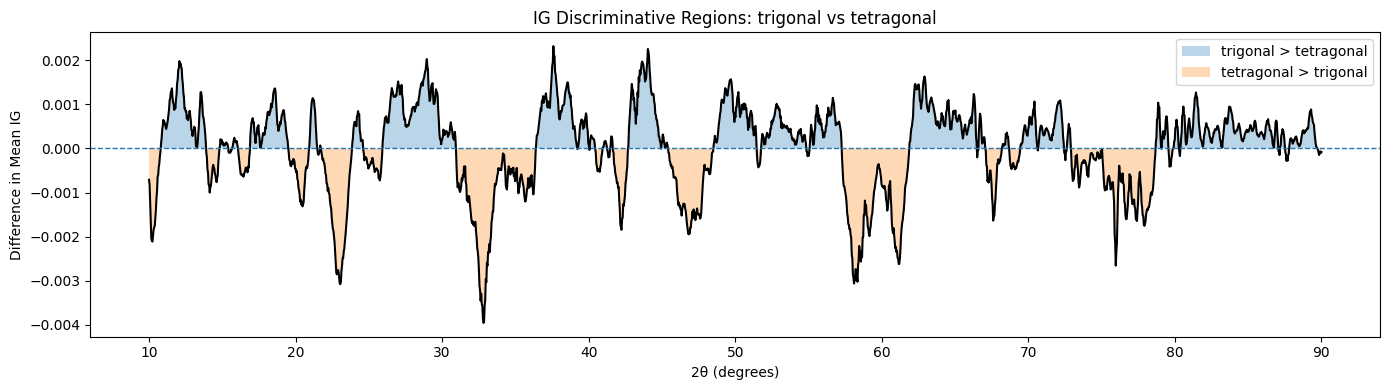

In [17]:
class_names = [
    'triclinic','monoclinic','orthorhombic',
    'tetragonal','trigonal','hexagonal','cubic'
]

diff = plot_class_difference(
    class_mean_ig,
    class_names,
    "trigonal",
    "tetragonal"
)
